# Lab 01 — The biosignal zoo & an acquisition audit

> **Type-2 lab — student version.** Fill in each `# TODO` (the answer cells raise `NotImplementedError` until you do), answer the **Checkpoint** questions, and complete the reflection cell, then re-run top to bottom. Instructor solutions are not distributed in this repository.

**Covers.** Chapter 1 — §1.4 (biosignal signatures), §1.6 (the taxonomy), §1.7 (task types), §1.9 (the pipeline).

**Biomedical question.** Is this recording fit for the question I want to ask of it?
**Task type (§1.7).** Measurement/Monitoring — a pre-analysis quality audit
**Information that must be preserved.** the band and morphology the downstream task needs (e.g. ECG ST content to 0.05 Hz)
**Main assumptions.** channels are labelled with correct units and sampling rates
**Primary diagnostic.** an acquisition audit: rate, missingness, clipping fraction, flatline, mains estimate
**Transfer challenge.** repeat the audit on a signal type you did not design for

*Self-contained: runs fully offline in a browser on a seeded synthetic signal — no data
files, no network. `load_signal()` calls a `load_from_open_dataset()` hook you can wire to a
real recording (wfdb / MNE / PhysioNet); it is **not** wired here, so the notebook announces
the fallback and continues.*

### Companion lab · *Biomedical Signal Processing & Data Analytics* (CM2013)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/labs/lab01_biosignal_zoo_and_acquisition_audit/lab01_biosignal_zoo_and_acquisition_audit.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/lab01_biosignal_zoo_and_acquisition_audit.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=lab01_biosignal_zoo_and_acquisition_audit.ipynb)

In [26]:
# --- shared setup (reproducible; offline fallback) ---
import numpy as np, matplotlib.pyplot as plt
from scipy import signal as sig
rng = np.random.default_rng(2013)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

def load_from_open_dataset(kind, fs, secs):
    """Real-data hook — fill in for your track (wfdb / MNE / PhysioNet). Not wired by
    default, so this lab runs fully offline on synthetic data."""
    raise NotImplementedError("real-data hook not configured")

def load_signal(kind, fs, secs):
    """Return (x, fs). Try the real-data hook; else ANNOUNCE and use a synthetic stand-in."""
    try:
        return load_from_open_dataset(kind, fs, secs)
    except NotImplementedError as e:
        print(f"[load_signal] {e}; using synthetic fallback.")
        t = np.arange(int(fs*secs))/fs
        return synth(kind, t, fs), fs

def synth(kind, t, fs):
    if kind == "ecg":
        beat = lambda tc: (1.0*np.exp(-((t-tc)/0.010)**2) - 0.15*np.exp(-((t-tc+0.04)/0.02)**2)
                           + 0.25*np.exp(-((t-tc-0.22)/0.03)**2))
        x = sum(beat(tc) for tc in np.arange(0.6, t[-1], 0.85))
        x += 0.05*np.sin(2*np.pi*50*t) + 0.02*rng.standard_normal(t.size)   # mains + noise
        x += 0.1*np.sin(2*np.pi*0.3*t)                                       # baseline wander
        return x
    return np.sin(2*np.pi*10*t) + 0.2*rng.standard_normal(t.size)


## 1. See it — load and look
Load a synthetic ECG and plot 5 s. Name three features you can see.

[load_signal] real-data hook not configured; using synthetic fallback.


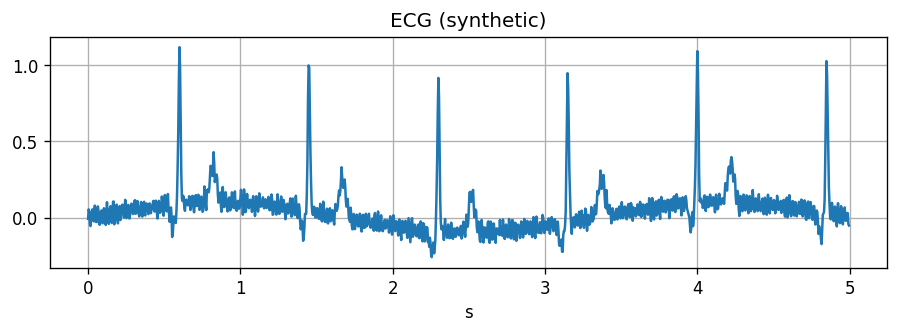

In [27]:
x, fs = load_signal("ecg", fs=250, secs=20)
t = np.arange(x.size)/fs
plt.figure(figsize=(9,2.5)); plt.plot(t[:int(5*fs)], x[:int(5*fs)]); plt.xlabel("s"); plt.title("ECG (synthetic)"); plt.show()
# Checkpoint: which artifacts are visible? (baseline wander? mains? noise?)

## 2. Build the acquisition audit
`# TODO` complete each metric. This one-page audit is the first thing you run on ANY new recording.

**Threshold-stability check (do this before the reflection):** re-run the audit with the flatline threshold at 0.1% / 1% / 5% of `np.ptp(x)`, the mains band at ±0.5 / ±1 / ±2 Hz around 50 Hz, and `nperseg` at 256 vs `4*fs`; tabulate `clip_frac` / `flat_frac` / `mains50_frac` for each setting and note which conclusions move.

In [33]:
def acquisition_audit(x, fs):
    audit = {}
    audit["duration_s"] = x.size / fs
    audit["fs"] = fs
    # missingness: fraction of NaN samples  (worked for you — the pattern for the rest)
    audit["missing_frac"] = float(np.mean(np.isnan(x)))

    # TODO clipping: define a "rail" as the signal's global max or min, HIT WITH EXACT
    #   EQUALITY to a neighbouring sample (a flat plateau at an extreme — not a single sharp
    #   sample like an R-peak, which touches the rail only once). Flag a sample only if it
    #   sits at a rail AND repeats its neighbour. Set audit["clip_frac"] = fraction of samples
    #   flagged. Expected on the clean signal: ~0. Worry if > 1%.
    #raise NotImplementedError("TODO: implement this — see the comment above")

    # ---------------------------------------------------------
    # Clipping
    # ---------------------------------------------------------
    # A sample is considered clipped if:
    # 1. It is exactly at the global maximum or minimum
    # 2. It is equal to a neighbouring sample

    # Define global limits
    # np.nanmax/np.nanmin are used so that NaN samples are neglected.
    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    # Has the signal has reached a global limit? Boolean.
    at_rail = (x == x_max) | (x == x_min)

    # IMPORTANT: we do not want to classify a single sharp peak as clipping. A
    # sample at the minimum/maximum may simply be a legitimate sharp peak.
    # Therefore, the lab defines clipping as a rail value that is also repeated
    # by a neighbour.

    # Check equality with a neighbour for each element in x.

    # Is a sample i equal to sample i-1?
    same_as_left = np.zeros(x.size, dtype=bool)
    same_as_left[1:] = (x[1:] == x[:-1])

    # Is a sample i equal to sample i+1?
    same_as_right = np.zeros(x.size, dtype=bool)
    same_as_right[:-1] = (x[:-1] == x[1:])

    # A sample is clipped if it is at a rail AND has an identical neighbouring
    # sample. This identifies a flat plateau at the rail.
    clipped = at_rail & (same_as_left | same_as_right)

    # Fraction of all sample identified as clipped.
    audit["clip_frac"] = float(np.mean(clipped))


    # TODO flatline: define a "flatline" window as a non-overlapping 1-second window whose
    #   peak-to-peak spread is a TINY FRACTION OF THE SIGNAL'S SCALE:
    #   np.ptp(window) < 0.01 * np.ptp(x). Set audit["flat_frac"] = fraction of 1-s windows
    #   flagged. Expected on the clean signal: ~0. Worry if > 1%.
    #raise NotImplementedError("TODO: implement this — see the comment above")

    # TODO mains: define the "narrow 50 Hz band" as 49-51 Hz. Use
    #   f, Pxx = sig.welch(x, fs, nperseg=4*fs) and set
    #   audit["mains50_frac"] = (band power in 49-51 Hz) / (total power).
    #   Expected on the clean signal: ~0.05 (the synthetic mains term).
    #raise NotImplementedError("TODO: implement this — see the comment above")
    return audit

acquisition_audit(x, fs)  # Checkpoint: is the mains fraction high enough to worry about?

{'duration_s': 20.0,
 'fs': 250,
 'missing_frac': 0.0,
 'at_rail': np.True_,
 'clip_frac': 0.0}

### Do the clipping/flatline detectors actually react to defects?
A metric you never see fire is untrustworthy. The clean ECG has neither defect, so both must read ~0; a hard-limited copy must trip `clip_frac`, and a spliced dead-lead segment must trip `flat_frac`.

In [ ]:
# --- sanity check: react to REAL defects, not to healthy peaks (numbers are computed live) ---
x_clipped = np.clip(x, -0.55, 0.55)                             # hard-limit -> the ADC 'rails'
x_dead = x.copy(); x_dead[int(3*fs):int(5*fs)] = x_dead[int(3*fs)]  # splice a 2 s disconnected-lead flatline
a0 = acquisition_audit(x, fs)
print(f"clean     : clip_frac={a0['clip_frac']:.4f}   flat_frac={a0['flat_frac']:.4f}")
print(f"clipped   : clip_frac={acquisition_audit(x_clipped, fs)['clip_frac']:.4f}   (was ~0 on clean)")
print(f"dead-lead : flat_frac={acquisition_audit(x_dead, fs)['flat_frac']:.4f}   (2 s of 20 s ~ 0.10)")

NotImplementedError: TODO: implement this — see the comment above

## 3. Make it fail — the wrong bandwidth
High-pass the ECG as if for *rhythm monitoring*, then ask whether it still supports *ST analysis*.

In [ ]:
# TODO apply a 0.5 Hz causal high-pass (monitoring-style) and compare the low-frequency content:
#   b, a = sig.butter(1, 0.5, "highpass", fs=fs); x_mon = sig.lfilter(b, a, x)
#   Then compare the 0.05-0.5 Hz Welch power (sig.welch(x, fs, nperseg=8*fs)) of x_mon vs x —
#   report the ratio (after/before); expect it to be < 0.3.
raise NotImplementedError("TODO: implement this — see the comment above")
# Checkpoint: plot x vs x_mon for t in [8.9, 9.6] s (there is a beat at ~9.1 s).
#   Done when you can report the ratio and state whether ST content down to 0.05 Hz
#   survives the high-pass (it does not).
raise NotImplementedError("TODO: implement this — see the comment above")

NotImplementedError: TODO: implement this — see the comment above

## 4. Transfer challenge
Repeat the audit on a signal type you did not design it for.

In [ ]:
x2, _ = load_signal("eeg", fs=250, secs=20)
acquisition_audit(x2, fs)
# Checkpoint: which metric is misleading on a beat-free signal, and why?

[load_signal] real-data hook not configured; using synthetic fallback.


NotImplementedError: TODO: implement this — see the comment above

## Reflection
1. Which conclusion about signal quality stayed stable across reasonable audit thresholds?
2. Which changed?
3. What evidence would you need before using this recording on a new population or device?
4. Which method would you investigate next, and why?

> *Your answers here.*